Sylvie TREUILLET | Begin with OpenCV in Python (ED MIPTIS)


<h1><center> Etape 1 : Read and display an image



## Prérequis : Python installé avec les librairies Numpy, Matplotlib et OpenCV


In [ ]:
# Import du module 'numpy' et renommé en 'np' (library for manipulating matrices anf multidimensional arrays)
import numpy as np
# Import du sous-module 'pyplot' du module 'matplotlib renommé en 'plt' (graphical library)
import matplotlib.pyplot as plt
# Import module 'cv2' (library OpenCV)
import cv2 as cv


## 1.1) Lire et afficher une image 
Le fichier doit être dans le même dossier par défaut, sinon il faut préciser le chemin d'accès

In [ ]:
# Lire le ficher image 
im1 = cv.imread('images/Pens.jpg', cv.IMREAD_COLOR)

In [ ]:
# Afficher l'image 
plt.imshow(im1)

In [ ]:
# Afficher les dimensions de l'image
im1.shape

## 1.2) Afficher seulement une partie de l'image

In [ ]:
# Afficher une partie
plt.imshow(im1[20:150,:,:])
plt.axis('off') 


In [ ]:
# Modifier le code pour n'afficher que le crayon noir
# A VOUS DE JOUER

## 1.3) Afficher chaque composante R,G,B séparément 

In [ ]:
# Séparer les composantes R, G et B
R=im1[:,:,0]
G=im1[:,:,1]
B=im1[:,:,2]
# R, G, B = cv.split(im1)

# Afficher l'image et ces 3 composantes RGB dans une figure en 4 quadrants
# La fonction subplot permet de décomposer une figure en plusieurs quadrants
# Ajouter le paramètre 'gray' dans la fonction plt.imshow(R, 'gray') pour afficher en niveaux de gris

plt.subplot(2, 2, 1)
plt.imshow(im1)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(R, 'gray')
plt.title('R')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(G, 'gray')
plt.title('G')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(B, 'gray')
plt.title('B')
plt.axis('off')

plt.show()

## 1.4) Tracer les valeurs des pixels le long d'une ligne

In [ ]:
# Choisir une ligne 
ligne = 155

# Tracer les intensités RGB le long de cette ligne sous la bande image

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.imshow(im1[ligne-20:ligne+20,:,:])
plt.axis('off')

plt.subplot(2, 1, 2)
plt.plot(im1[ligne,:,0], 'r', label='R')
plt.plot(im1[ligne,:,1], 'g', label='G')
plt.plot(im1[ligne,:,2], 'b', label='B')

#plt.figure(figsize=(10, 4))
plt.title('Valeur RGB le long de la Ligne ' + str(ligne))
plt.xlabel('Position')
plt.ylabel('Valeur')
plt.legend()
plt.show()


## 1.5) Afficher les valeurs d'un pixel

In [ ]:
# Choisir un pixel et afficher le voisinage 3x3 coloré centré sur le pixel
x=215
y=ligne

print ('R=', im1[y,x,0])
print ('G=', im1[y,x,1])
print ('B=', im1[y,x,2])

# Afficher un patch de la couleurs correspondante (voisinage centré sur le pixel)
plt.title('Couleur correspondante')
plt.imshow(im1[ligne-1:ligne+1,x-1:x+1,:])
plt.axis('off')

In [ ]:
# A VOUS DE JOUER
# Afficher les profils ligne dans les différentes parties en couleur et en niveaux de gris de l'image "MireTV.jpg"


Modifier l'abcisse du pixel sur la ligne dans le code ci-dessus pour voir les coordonnées RGB d'autres couleurs.

<h1><center> Etape 2 : Histogramme d'une image

## 2.1) What is histogram ?

L’histogramme d’une image représente la distribution des niveaux de gris en cumulant l'occurrence de chaque valeur (généralement entre 0 et 255). Il donne une estimation de la densité de probabilité de l’intensité lumineuse. C’est l’outil de base pour fixer les paramètres d’acquisition (gain, offset, gamma), améliorer le contraste de l’image, ou encore choisir un bon seuil de binarisation.

It is a plot with pixel values (ranging from 0 to 255, not always) in X-axis and corresponding number of pixels in the image on Y-axis. It gives global information about contrast, brightness, intensity distribution of that image.


In [ ]:
# Définir une fonction qui calcule l'histogramme d'une image en 256 niveaux
def show_hist(image) : 
    # créer un vecteur de taille 256 valeurs initialisées à zéro 
    hist = np.zeros(256)
    # balayer l'image et incrémenter le nombre de pixels pour chacun des niveaux
    for y in range(0, image.shape[0]) :
        for x in range(0, im.shape[1]) :
            hist[image[y,x]] += 1
    # Afficher la courbe
    plt.plot(np.arange(0, 256), hist)
    plt.title('histogram')

In [ ]:
# Ouvrir une image en niveaux de gris, afficher l'image et son histogramme à côté
im = cv.imread("Images/lena.bmp", cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 5))
plt.subplot (1,2,1)
plt.imshow(im, 'gray')
plt.axis('off')
plt.subplot (1,2,2)
show_hist(im)

Que représentent l’axes des X et des Y de l'histogramme ? Modifier le code ci-dessus pour donner un label à chaque axe, et vérifier en ré-exécutant.

Observer l’histogramme des diverses images à votre disposition en modifiant le nom du fichier dans le code ci-dessus :
pout.tif, cameraman.tif, rice.tif, tire.tif, circuit.tif, ic.tif,...


In [ ]:
# Il est préférable de faire appel à une fonction de la librairie pyplot pour tracer l'histogramme
plt.hist(im.ravel(),256,[0,256]); plt.show()

## 2.2) Réglage du gain et de l'offset d'une caméra

Les réglages de $gain$ et d'$offset$ correspondent à la transformation de l'intensité des niveaux de gris :
$$
I_t = Gain * I + Offset
$$

Ouvrir une image en niveaux de gris et étudier l’influence de différents réglages du $gain$ et de l’$offset$ sur une image, en affichant l'histogramme à côté (utiliser de préférence la fonction de la librairie pyplot).

Comment agissent ces deux paramètres sur l’histogramme ?


In [ ]:
# A VOUS DE JOUER 


Quel histogramme doit-on rechercher lors de l’acquisition d’une image pour utiliser pleinement la dynamique du capteur et avoir un bon contraste ?

## 2.3) Egalisation d'histogramme
Supposons que les niveaux de gris de l'image n'utilisent pas complètement l'intervalle $[0,255]$, il est possible de faire un étirement des niveaux gris en appliquant la formule :
$$
    im_t = 255 * (im - gmin) / (gmax - gmin) 
$$
avec $gmin$ et $gmax$, les niveaux de gris minimum et maximum dans l'image originale. On accède au min et max d'un tableau par les fonctions np.min(array) et np.max(array). 

Mais cet étirement n'améliorera pas le contraste. Pour améliorer le contraste, on peut réaliser une égalisation d'histogramme : c'est une opération qui vise à rendre l'histogramme le plus plat possible, donc une distribution relativement homogène des niveaux de gris, par la fonction cv.equalizeHist(Image).

Afficher l'image "pout.tif" avant et après égalisation son histogramme.  

Link : https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html


In [ ]:
# A VOUS DE JOUER


Recommencez avec l'image "tire.tif". 

<h1><center> Etape 3 : Seuillage et Binarisation

La binarisation a pour but de séparer les pixels comme appartenant à 2 catégories, communément appelés objet (blanc=1) ou fond (noir=0) en appliquant un seuil sur les niveaux de gris.

Link : https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html


## 3.1) Test de différentes méthodes de seuillage

Comparer les trois méthodes de seuillage suivantes sur l'image "Sudoku.jpg" :
- seuillage global manuel (seuil choisi par vous)
- seuillage adaptatif (différentes options pour les paramètres) 
- seuillage automatique d'OTSU

Recommencer sur l'image "rice.tif", "ic.tif", "coins.png". Jouer sur les paramètres des seuillages pour analyser leurs effets (consulter le tutorial indiqué ci-dessus).

In [ ]:
# A VOUS DE JOUER


## 3.2) Analyse en composantes connexes

Après avoir binarisé l'image des grains de riz (rice.tif), on souhaite identifier chaque grain pour faire une analyse en taille. Il est nécessaire de réaliser une labélisation ou étiquetage en composantes connexes pour regrouper les pixels appartenant à un même objet (connected-component labeling, blob extraction, region labeling, in English), par l'appel de la fonction cv.connectedComponents(). Visualiser les résultats.

Afficher le nombre d'objets détectés.

Créer un tableau qui consigne la surfade de chaque objet. Afficher les surfaces, la moyenne et écart-type.


In [ ]:
# A VOUS DE JOUER



## 3.3) Revenons à la couleur

In [ ]:
# Ouvrir une image en couleur et tracer histogrammes des 3 composantes sur un seul graphique
im = cv.imread('Pens.jpg')
plt.figure(figsize=(12, 4))

plt.subplot (1,2,1)
plt.imshow(im, 'gray')

plt.subplot (1,2,2)
color = ('b','g','r')
for i,col in enumerate(color):
 hist = cv.calcHist([im],[i],None,[256],[0,256])
 plt.plot(hist,color = col)
 plt.xlim([0,256])
plt.show()

Comparer les trois images de luminance créées par les formules :
- L = (R+G+B)/3
- V = max(R,G,B)
- Y = 0,30 R + 0,59 G + 0,11 B

In [ ]:
# A VOUS DE JOUER 

Tester la fonction cv2.merge((bande1, bande2, bande3)) qui permet de permuter l'ordre des bandes sur les images 'poivrons.jpg' ou 'candies.jpg' 

In [ ]:
# A VOUS DE JOUER 

Essayer d’isoler les zones rouges puis bleues dans l'image "Parrots.jpg" par des seuillages.
Recommencer avec l'image "candies.jpg"

In [ ]:
# A VOUS DE JOUER 

Note: il est parfois intéressant de changer d'espace couleurs pour faciliter le seuillage, en utilisant l'espace HSV, per exemple. 

<h1><center> Etape 4 : Convolution 2D et Filtrage

Lien : https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html

## 4.1) Convolution 2D

Réaliser plusieurs fois une convolution par un moyenneur 3x3 en appliquant la convolution sur l’image filtrée obtenue et
visualiser les résultats à chaque étape.
Quel effet produit le filtre moyenneur ?
Comparer le résultat obtenu en filtrant deux fois de suite l’image avec le moyenneur 3x3 et celui obtenu par un filtrage par le masque 5x5 suivant. Conclusion.

Qu'appelle-t-on un effet de bord ?

Essayer un filtre dérivatif comme Sobel :  https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html


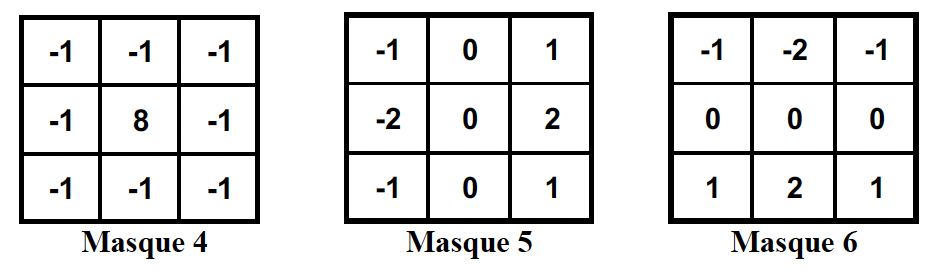

Soustraire à l’image moyennée par le masque 3x3, le centième du résultat du filtrage par le
masque 4. Quel effet produit cette combinaison ?

Visualiser la valeur absolue de la somme des images résultantes des filtrages par les masques
5 et 6. Que représente-elle ?

Quelle relation mathématique relie les masques 5 et 6 ?

Vérifier que le masque 5 est équivalent à la combinaison des filtres mono dimensionnels
[1 2 1] T * [-1 0 1]. Que produisent individuellement ces deux filtres ?



In [ ]:
# A VOUS DE JOUER

## 4.2) Debruitage
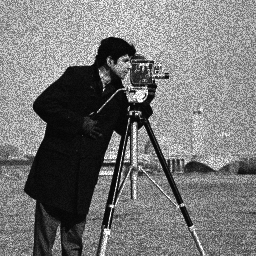

L’acquisition d’images numériques est entâchée par différentes sources de bruit. On peut utiliser différentes méthodes de filtrage pour réduire le bruit.

Quatre types de bruit ont été ajoutés à l’image Cameraman : 
- Bruit additif gaussien ou impulsionnel : $I = I+B$
    - Cam_Gaus01 : ajout d’un bruit blanc centré de variance 0.01
    - Cam_Gaus005 : ajout d’un bruit blanc centré de variance 0.005
    - Cam_Imp01 : N pixels blancs ou noirs aléatoires, N=0.01*prod(size(I))
    - Cam_Imp05 : N pixels blancs ou noirs aléatoires, N=0.05*prod(size(I))
- Bruit multiplicatif (speckle) : $I = I+I*B$
    - Cam_Spe01 : B centré uniformément réparti de variance 0.01
    - Cam_Spe04 : B centré uniformément réparti de variance 0.04
- Bruit de Poisson : Cam_Poisson


Appliquer un filtre moyenneur 3x3 sur les 4 images avec bruit (additif gaussien ou impulsionnel) et comparer les résultats. Qu’en concluez-vous ?


In [ ]:
# A VOUS DE JOUER

Tester d'autres filtrages sur ces 4 mêmes images, notamment le filtrage Médian.  

Le filtrage médian consiste à conserver la valeur médiane de chaque voisinage pour l’affecter au pixel central (la taille du voisinage peut varier). Contrairement aux filtres précédents, cette opération n'est pas linéaire (elle ne peut pas se faire par une convolution), le filtre médian fait partie de la famille des filtres d’ordre non linéaires.

Sur quel type de bruit le filtre médian est-il particulièrement efficace ? Quel est le principal avantage de ce filtre par rapport à un moyenneur ?

Pour aller plus loin, vous pouvez vous documenter sur d'autres méthodes de filtrage, comme les filtres adaptatif, bilatéral, etc. 

Link https://docs.opencv.org/4.x/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html


In [ ]:
# A VOUS DE JOUER

<h1><center> Etape 5 : Transformée de Fourier

Lien : https://docs.opencv.org/4.x/de/dbc/tutorial_py_fourier_transform.html

Visualiser le module de la transformée de Fourier (TF) des images suivantes : cameraman.gif, bureau.gif, testpat1.tif, testpat2.tif, circuit.tif, ic.tif, ic45.tif

Pourquoi est-il préférable de visualiser le log du module de la TF ? 

Que produit une rotation de l’image sur la TF ? 

Que représente l’élément central ? 

Quelle relation existe-t-il entre cet élément, la moyenne et la taille de l’image ? 

Ecrire un code permettant d’ôter à la TF une partie des fréquences (voir figure ci-dessous) et visualiser l'image reconstruite par TF inverse. Visualiser sur une même figure, l’image originale, les images filtrées et leurs TF respectives. Analyser les résultats. 

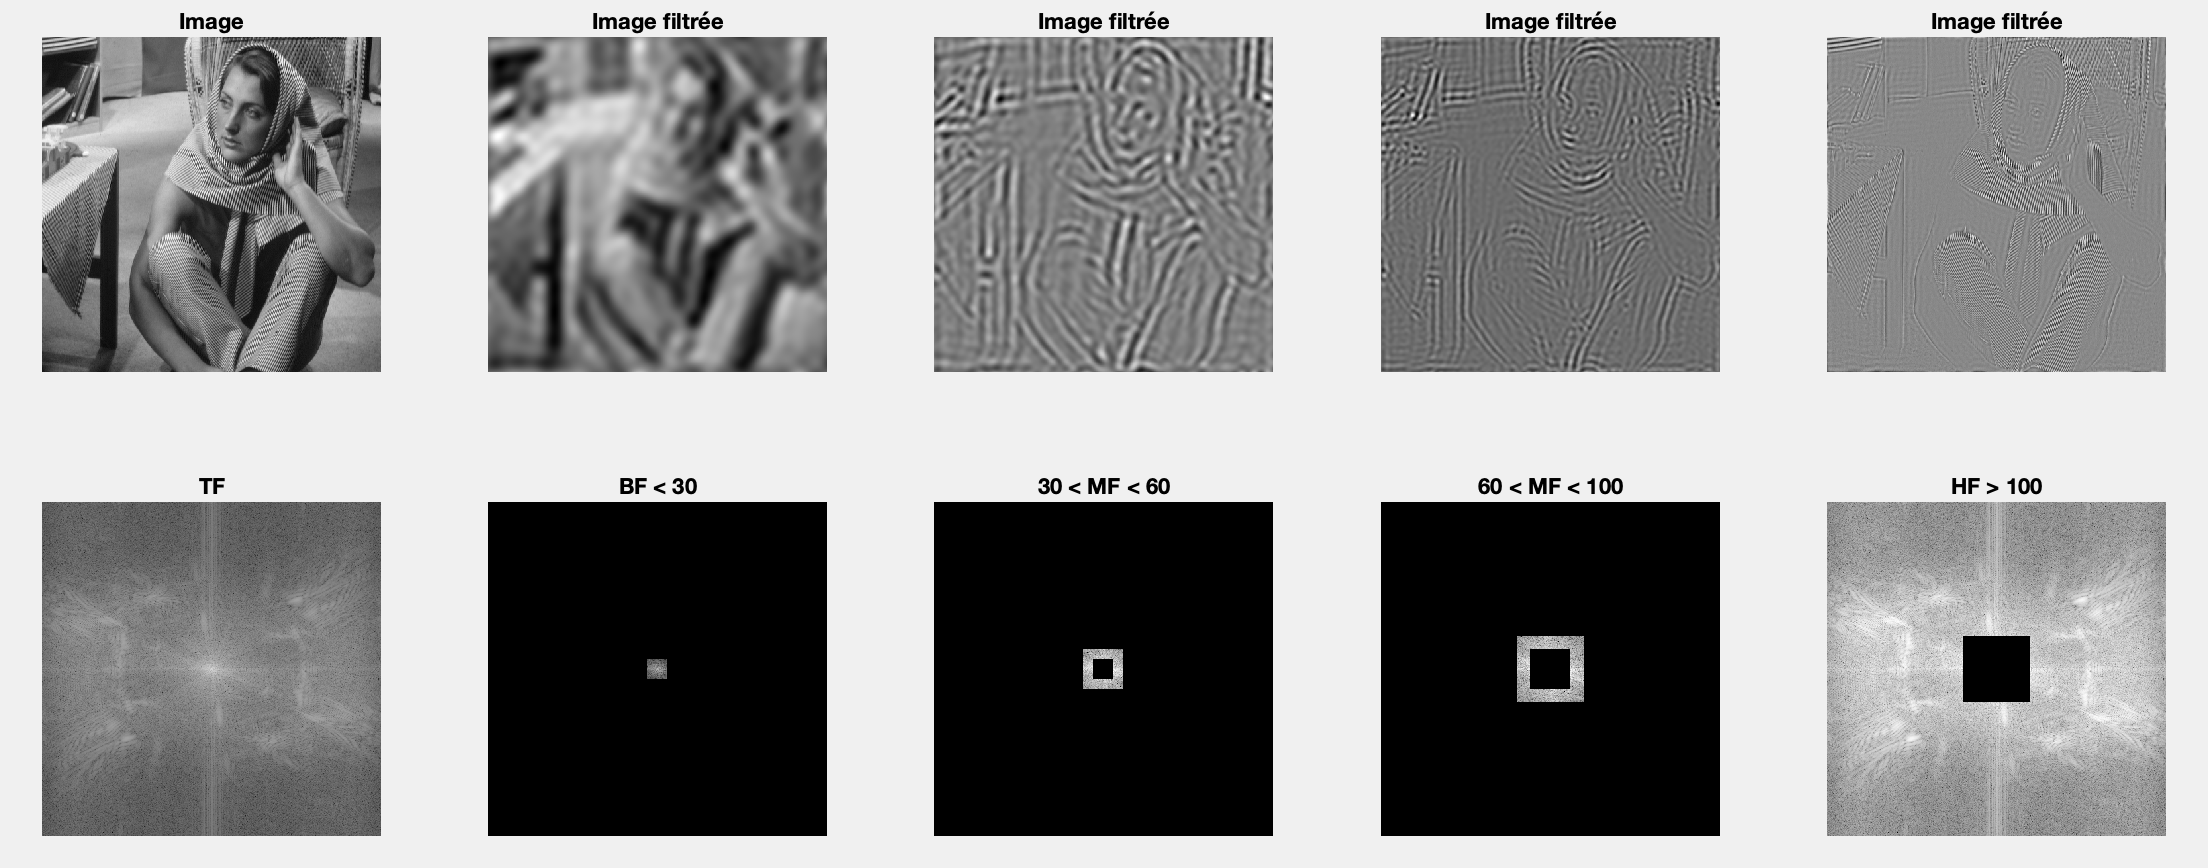


In [ ]:
# A VOUS de JOUER

<h1><center> Etape 6 : Transformations géométriques




Lien : https://docs.opencv.org/4.x/da/d6e/tutorial_py_geometric_transformations.html

In [ ]:
# A VOUS de JOUER